**Laboratorio de Métodos Cuantitativos Aplicados a la Gestión**

---

# **Clase 10 - Funciones marginales y elasticidades**

En esta clase de **Laboratorio de Métodos Cuantitativos Aplicados a la Gestión**, continuaremos explorando el **Cálculo diferencial, aplicado (II)**. Nos enfocaremos en conceptos clave como:

*   Recap de la aplicación de estos conceptos para encontrar puntos óptimos en modelos económicos, como la cantidad donde el **Ingreso Marginal (MR) es igual al Costo Marginal (MC)**.
*   La **Elasticidad Precio de la Demanda**, analizando tanto la formulación continua (usando derivadas) como la formulación discreta o de arco (aplicada a datos reales).
*   Trabajaremos con un caso práctico utilizando un conjunto de datos real (el dataset de aguacates) para calcular y analizar la elasticidad precio de la demanda por región.
*   Visualizaremos los resultados para entender mejor las diferencias en la sensibilidad al precio entre distintas regiones.

---

**La pregunta que ordena toda la clase** es una sola: *si subo el precio un 1%, ¿cuánto cae la
cantidad que vendo?* De la respuesta depende si conviene subir el precio o bajarlo, y es la pregunta
que en la Clase 11 vamos a terminar de responder optimizando.

La elasticidad es la forma de contestarla **sin depender de las unidades**: no dice "caen 15
clientes", dice "cae un 3%". Por eso se puede comparar entre productos, entre regiones y entre
países, que es justamente lo que vamos a hacer con el dataset de paltas.



In [1]:
#librerias de la clase
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
import scipy as sc
import pandas as pd


In [2]:
#!pip install numpy, sympy,matplotlib,scipy,pandas

#Recordando
## Encontrar la cantidad donde MR = MC

Vamos a definir simbólicamente una función de demanda y una función de costo para encontrar la cantidad donde el Ingreso Marginal (MR) es igual al Costo Marginal (MC).

In [3]:
# Definir variables simbólicas
q, p, a, b, c, d = sp.symbols('q p a b c d')

def precio_demanda(q, a, b):
    return a - b*q # a es el precio maximo

def costo_total(q, c, d):
    return c*q + d*q**2

# Ingreso Total (TR = p * q)
TR = precio_demanda(q, a, b) * q

# Ingreso Marginal , la derivada del ingreso
MR = sp.diff(TR, q)

# Costo Marginal, la derivada del costo
MC = sp.diff(costo_total(q, c, d), q)

# Ecuación para encontrar la cantidad donde MR = MC
ecuacion_equilibrio = sp.Eq(MR - MC, 0) #.eq crea una ecuacion simbolica


print("Función de Ingreso Total (TR):")
display(TR)
print("\nFunción de Ingreso Marginal (MR):")
display(MR)
print("\nFunción de Costo Marginal (MC):")
display(MC)
print("\nEcuación MR - MC = 0:")
display(ecuacion_equilibrio)

# Resolver la ecuación para q
solucion_q = sp.solve(ecuacion_equilibrio, q) #ahora dada la ecuacion de equilibrio, la valuamos en q. es para obtener la ecuacion de forma simbolica

print("\nSolución para q (donde MR = MC):")
solucion_q




Función de Ingreso Total (TR):


q*(a - b*q)


Función de Ingreso Marginal (MR):


a - 2*b*q


Función de Costo Marginal (MC):


c + 2*d*q


Ecuación MR - MC = 0:


Eq(a - 2*b*q - c - 2*d*q, 0)


Solución para q (donde MR = MC):


[(a - c)/(2*(b + d))]

In [4]:
#----------------------#

valor_en_q1 = ecuacion_equilibrio.subs(q, 1) #lo valuamos en 1

display(valor_en_q1)

Resultado1 =sp.simplify(valor_en_q1)#simplificamos para interpretar

display(Resultado1)

Eq(a - 2*b - c - 2*d, 0)

Eq(a, 2*b + c + 2*d)

---

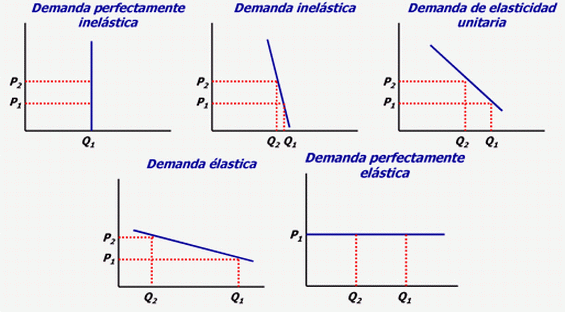

**Elasticidad Precio de la Demanda** 🤔

Piensa en esto como qué tan "sensibles" son los compradores a los cambios en el precio 🏷️ de un producto.

*   **Si la demanda es Elástica:** Si el precio sube, la cantidad demandada disminuye significativamente 📉. Esto suele ocurrir cuando hay muchos sustitutos disponibles y los consumidores pueden cambiar fácilmente a otras opciones.
*   **Si la demanda es Inelástica:** Si el precio sube, la cantidad demandada cambia muy poco 🤷‍♀️. Esto sucede a menudo con productos necesarios o cuando no hay buenos sustitutos cercanos, por lo que los consumidores siguen comprando a pesar del aumento de precio.

En resumen: Mide cuánto cambia la cantidad que la gente compra cuando cambia el precio.

## Elasticidad Precio de la Demanda (Continua)

La elasticidad precio de la demanda ($\epsilon_p$) para una función de demanda continua $Q = f(P)$ se define como:

$$ \epsilon_p = \frac{\% \Delta Q}{\% \Delta P} = \frac{\frac{dQ}{Q}}{\frac{dP}{P}} = \frac{dQ}{dP} \cdot \frac{P}{Q} $$

Donde:
- $\frac{dQ}{dP}$ es la derivada de la cantidad demandada con respecto al precio.
- $P$ es el precio.
- $Q$ es la cantidad demandada.

## Caso Hipotético: Elasticidad Precio de la Demanda (Continua)

Vamos a considerar una función de demanda lineal hipotética y calcular la elasticidad precio de la demanda en un punto específico utilizando la fórmula continua.

In [5]:
# Definir variables simbólicas
p, q = sp.symbols('p q')

#q=1000 - 500*p
def cantidad_demandada(p):
    return 1000 - 500*p

# Calculamos la derivada de Q con respecto a P
dQ_dP = sp.diff(cantidad_demandada(p), p)

print("Función de Cantidad Demandada Q(P):")
display(cantidad_demandada(p))
print("\nDerivada de la Cantidad Demandada con respecto al Precio (dQ/dP):")
display(dQ_dP)



Función de Cantidad Demandada Q(P):


1000 - 500*p


Derivada de la Cantidad Demandada con respecto al Precio (dQ/dP):


-500

In [6]:
# Ahora, calculamos la elasticidad en un punto específico, por ejemplo, cuando el precio es P = 1.5
P0 = 1.5
Q0 = cantidad_demandada(P0)
#1000 - 500*1.5 --> q=1000 - 500*p

# Asegurarnos de que Q0 no sea cero para evitar división por cero
if Q0 != 0:
    # Calcular la elasticidad precio de la demanda continua en P0
    elasticidad_punto = dQ_dP * (P0 / Q0)

    print(f"\nPrecio (P0): {P0}")
    print(f"Cantidad Demandada en P0 (Q0): {Q0}")
    print(f"Elasticidad Precio de la Demanda en P = {P0}:")
    display(abs(elasticidad_punto)) # abs para aplicar modulo

    # Interpretación
    if abs(elasticidad_punto) > 1: #abs() nos devuelve el valor absoluto de un numero
        print("\nInterpretación: La demanda es Elástica en este punto (|Ep| > 1).")
    elif abs(elasticidad_punto) < 1:
        print("\nInterpretación: La demanda es Inelástica en este punto (|Ep| < 1).")
    else:
        print("\nInterpretación: La demanda es de Elasticidad Unitaria en este punto (|Ep| = 1).")
else:
    print(f"\nLa cantidad demandada en P = {P0} es cero, no se puede calcular la elasticidad en este punto.")


Precio (P0): 1.5
Cantidad Demandada en P0 (Q0): 250.0
Elasticidad Precio de la Demanda en P = 1.5:


3.00000000000000


Interpretación: La demanda es Elástica en este punto (|Ep| > 1).


## Rangos e Interpretación de la Elasticidad Precio de la Demanda ($\epsilon_p$)

La elasticidad precio de la demanda nos indica cuánto cambia la cantidad demandada ante un cambio en el precio. La interpretación se basa en el **valor absoluto** de $\epsilon_p$, ya que la elasticidad precio de la demanda casi siempre es negativa (debido a la ley de la demanda, que establece una relación inversa entre precio y cantidad).

*   **Demanda Elástica:** $|\epsilon_p| > 1$
    *   **Significado:** La cantidad demandada es **muy sensible** a los cambios en el precio. Un pequeño cambio porcentual en el precio provoca un cambio porcentual **mayor** en la cantidad demandada.
    *   **Implicación:** Las empresas con productos de demanda elástica suelen ser cautelosas al subir precios, ya que podrían perder una parte significativa de sus ventas.

*   **Demanda Inelástica:** $|\epsilon_p| < 1$
    *   **Significado:** La cantidad demandada es **poco sensible** a los cambios en el precio. Un cambio porcentual en el precio provoca un cambio porcentual **menor** en la cantidad demandada.
    *   **Implicación:** Las empresas con productos de demanda inelástica pueden tener más margen para ajustar precios sin que sus ventas se vean drásticamente afectadas (aunque aún existe un límite).

*   **Demanda de Elasticidad Unitaria:** $|\epsilon_p| = 1$
    *   **Significado:** La cantidad demandada cambia en el mismo porcentaje que el precio. Un cambio porcentual en el precio provoca un cambio porcentual **igual** en la cantidad demandada.

*   **Demanda Perfectamente Elástica:** $|\epsilon_p| = \infty$
    *   **Significado:** Cualquier pequeño aumento de precio provoca que la cantidad demandada caiga a cero. La demanda es infinitamente sensible al precio. (Caso teórico, a menudo asociado con competencia perfecta).

*   **Demanda Perfectamente Inelástica:** $|\epsilon_p| = 0$
    *   **Significado:** La cantidad demandada no cambia en absoluto, sin importar el cambio de precio. La demanda no es sensible al precio. (Caso teórico, a menudo asociado con bienes esenciales sin sustitutos).



---
## ⚠️ La elasticidad es una propiedad del **punto**, no de la curva

Acá hay un error que se comete todo el tiempo, incluso en informes profesionales: decir *"la demanda
de este producto es elástica"*, como si fuera una característica del producto.

**No lo es.** Sobre una misma demanda lineal, la elasticidad **cambia en cada punto**, y no un
poquito: va desde $-\infty$ hasta $0$. Recién calculamos $\varepsilon_p = -3$ para $P = 1{,}5$. Ese
$-3$ vale **para ese precio**, y para ningún otro.

La razón se ve en la fórmula:

$$\varepsilon_p = \underbrace{\frac{dQ}{dP}}_{\text{constante en una recta}} \cdot \underbrace{\frac{P}{Q}}_{\text{cambia en cada punto}}$$

En una demanda lineal la pendiente $dQ/dP$ es la misma en todos lados, pero el cociente $P/Q$ no:
cuando el precio es alto la cantidad es chica, así que $P/Q$ es enorme y la demanda es **muy
elástica**; cuando el precio es bajo pasa lo contrario.

Calculémoslo sobre la misma demanda de recién.


In [7]:
# Trabajamos simbólicamente con la MISMA demanda: Q(P) = 1000 - 500P
p = sp.symbols("p", positive=True)

Q = 1000 - 500*p
dQ_dp = sp.diff(Q, p)

# La elasticidad como FUNCIÓN del precio, no como un número suelto
elasticidad = sp.simplify(dQ_dp * p / Q)

print("Demanda         Q(P) =", Q)
print("Pendiente      dQ/dP =", dQ_dp, "  ← constante")
print("Elasticidad      ε(P) =", elasticidad, "  ← función de P")

# Evaluémosla a lo largo de toda la curva
print(f"\n{'Precio':>8}{'Cantidad':>12}{'ε':>10}   Interpretación")
print("-" * 55)
for precio in [0.2, 0.5, 1.0, 1.5, 1.8]:
    q_val = float(Q.subs(p, precio))
    e_val = float(elasticidad.subs(p, precio))
    if   abs(e_val) > 1: tipo = "Elástica"
    elif abs(e_val) < 1: tipo = "Inelástica"
    else:                tipo = "Elasticidad unitaria"
    print(f"{precio:>8.2f}{q_val:>12.0f}{e_val:>10.2f}   {tipo}")


Demanda         Q(P) = 1000 - 500*p
Pendiente      dQ/dP = -500   ← constante
Elasticidad      ε(P) = p/(p - 2)   ← función de P

  Precio    Cantidad         ε   Interpretación
-------------------------------------------------------
    0.20         900     -0.11   Inelástica
    0.50         750     -0.33   Inelástica
    1.00         500     -1.00   Elasticidad unitaria
    1.50         250     -3.00   Elástica
    1.80         100     -9.00   Elástica


### 💰 Para qué sirve saber esto: la elasticidad manda sobre el ingreso

Mirá la tabla de arriba y fijate que hay un punto donde $\varepsilon_p = -1$ exactamente. Ese punto
no es una curiosidad matemática: es **donde el ingreso total es máximo**. Y no es casualidad, porque
la elasticidad es literalmente lo que decide si subir el precio suma o resta:

| Si la demanda es… | Y subís el precio 1%… | Entonces el ingreso… | Conviene |
|---|---|---|---|
| **Elástica** ($\|\varepsilon\| > 1$) | la cantidad cae **más** de 1% | **baja** 📉 | **bajar** el precio |
| **Unitaria** ($\|\varepsilon\| = 1$) | la cantidad cae exactamente 1% | **no cambia** ➡️ | ya estás en el máximo |
| **Inelástica** ($\|\varepsilon\| < 1$) | la cantidad cae **menos** de 1% | **sube** 📈 | **subir** el precio |

La lógica es de una línea: el ingreso es $P \times Q$. Si el porcentaje que ganás por precio es mayor
que el porcentaje que perdés por cantidad, ganás. La elasticidad es exactamente la comparación entre
esos dos porcentajes.

Veámoslo en un gráfico.


Ingreso total          I(P) = -500*p**2 + 1000*p
Precio que maximiza I        = 1
Precio donde ε = -1          = 1

→ Son EL MISMO precio. No es coincidencia: dI/dP = 0  ⟺  ε = -1.


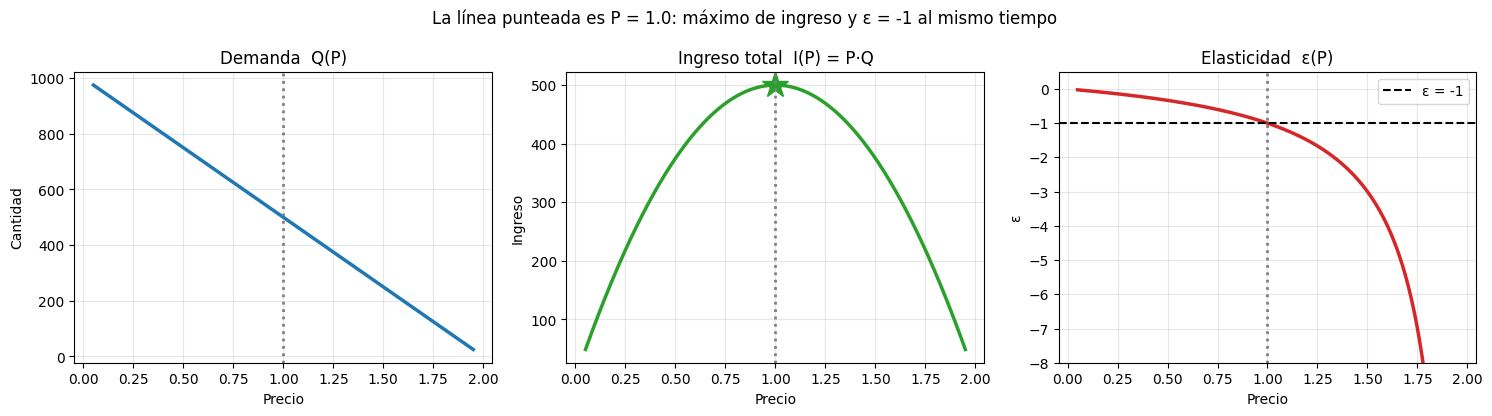

In [8]:
# Ingreso total = P × Q
ingreso = sp.expand(p * Q)
p_optimo = sp.solve(sp.diff(ingreso, p), p)[0]
p_unitaria = sp.solve(sp.Eq(elasticidad, -1), p)[0]

print(f"Ingreso total          I(P) = {ingreso}")
print(f"Precio que maximiza I        = {p_optimo}")
print(f"Precio donde ε = -1          = {p_unitaria}")
print(f"\n→ Son EL MISMO precio. No es coincidencia: dI/dP = 0  ⟺  ε = -1.")

# Gráfico
p_vals = np.linspace(0.05, 1.95, 400)
Q_f, I_f, e_f = (sp.lambdify(p, expr) for expr in (Q, ingreso, elasticidad))

fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))

ax[0].plot(p_vals, Q_f(p_vals), lw=2.5)
ax[0].set_title("Demanda  Q(P)"); ax[0].set_ylabel("Cantidad")

ax[1].plot(p_vals, I_f(p_vals), lw=2.5, color="tab:green")
ax[1].plot(float(p_optimo), float(ingreso.subs(p, p_optimo)), "*", ms=20, color="tab:green")
ax[1].set_title("Ingreso total  I(P) = P·Q"); ax[1].set_ylabel("Ingreso")

ax[2].plot(p_vals, e_f(p_vals), lw=2.5, color="tab:red")
ax[2].axhline(-1, color="black", ls="--", label="ε = -1")
ax[2].set_ylim(-8, 0.5)
ax[2].set_title("Elasticidad  ε(P)"); ax[2].set_ylabel("ε")
ax[2].legend()

for a in ax:
    a.axvline(float(p_optimo), color="gray", ls=":", lw=2)
    a.set_xlabel("Precio"); a.grid(alpha=.3)

fig.suptitle(f"La línea punteada es P = {float(p_optimo)}: máximo de ingreso y ε = -1 al mismo tiempo",
             fontsize=12)
plt.tight_layout()
plt.show()


> 💼 **Cómo se usa esto en una reunión.** Si alguien pregunta "¿subimos el precio?", la respuesta no
> se busca en el precio, se busca en la elasticidad **en el precio actual**. Si hoy estás a la
> **derecha** del punteado (precios altos, zona elástica), subir el precio te hace **perder**
> ingreso. Si estás a la **izquierda** (precios bajos, zona inelástica), subirlo te hace ganar.
>
> Y notá el matiz que importa: el máximo del gráfico del medio maximiza el **ingreso**, no el
> **beneficio**. Para el beneficio hay que meter los costos, y ahí el precio óptimo se corre para
> arriba. Eso es exactamente lo que resolvemos en el **Caso 3 de la Clase 11**.


---

## Elasticidad Precio de la Demanda (Discreta o Arco)

La elasticidad precio de la demanda ($\epsilon_p$) para datos discretos, a menudo llamada **elasticidad arco**, se calcula entre dos puntos $(P_1, Q_1)$ y $(P_2, Q_2)$ utilizando el método del punto medio para evitar sesgos. La fórmula es:

$$ \epsilon_p = \frac{\frac{Q_1 - Q_0}{(Q_1 + Q_0)/2}}{\frac{P_1 - P_0}{(P_1 + P_0)/2}} $$

Donde:
- $(P_1, Q_1)$ son el precio y la cantidad en el punto inicial.
- $(P_0, Q_0)$ son el precio y la cantidad en el punto final.
- El denominador en cada fracción es el promedio del precio o la cantidad en los dos puntos.

## Ejemplo Hipotético: Elasticidad Precio de la Demanda (Discreta o Arco)

Vamos a calcular la elasticidad arco entre dos puntos de precio y cantidad hipotéticos.

In [9]:
# Punto 1: Precio P1, Cantidad Q1
P1 = 10
Q1 = 100

# Punto 2: Precio P2, Cantidad Q2
P2 = 12
Q2 = 80

# Cambio porcentual en la cantidad (usando punto medio)
porcentaje_cambio_Q = (Q2 - Q1) / ((Q1 + Q2) / 2)

# Cambio porcentual en el precio (usando punto medio)
porcentaje_cambio_P = (P2 - P1) / ((P1 + P2) / 2)

# Calcular la elasticidad
if porcentaje_cambio_P != 0:
    #ESTA ES LA ECUACION!!
    elasticidad_arco = porcentaje_cambio_Q / porcentaje_cambio_P
    print(f"Punto 1: Precio = {P1}, Cantidad = {Q1}")
    print(f"Punto 2: Precio = {P2}, Cantidad = {Q2}")
    print(f"\nCambio porcentual en la cantidad: {porcentaje_cambio_Q:.4f}")
    print(f"Cambio porcentual en el precio: {porcentaje_cambio_P:.4f}")
    print(f"\nElasticidad Precio de la Demanda (Arco): {elasticidad_arco:.4f}")

    # Interpretación
    if abs(elasticidad_arco) > 1:
        print("\nInterpretación: La demanda es Elástica en este rango (|Ep| > 1).")
    elif abs(elasticidad_arco) < 1:
        print("\nInterpretación: La demanda es Inelástica en este rango (|Ep| < 1).")
    else:
        print("\nInterpretación: La demanda es de Elasticidad Unitaria en este rango (|Ep| = 1).")
else:
    print("El cambio de precio es cero, no se puede calcular la elasticidad.")

Punto 1: Precio = 10, Cantidad = 100
Punto 2: Precio = 12, Cantidad = 80

Cambio porcentual en la cantidad: -0.2222
Cambio porcentual en el precio: 0.1818

Elasticidad Precio de la Demanda (Arco): -1.2222

Interpretación: La demanda es Elástica en este rango (|Ep| > 1).


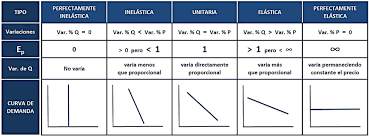

---
#Vayamos a un caso particular 🥑 🥑

In [10]:
# Ya no hace falta montar Google Drive: los datos se leen por URL del repositorio,
# asi el notebook corre igual en Colab, en la facultad y en tu casa.

In [11]:
# (Antes aca se listaba Google Drive. Ya no hace falta: los datos vienen por URL.)

In [12]:
Palta_df=pd.read_csv("https://raw.githubusercontent.com/Datso653/Laboratorio-de-metodos-Cuantitativos-Aplicados-a-la-gestion/main/DF/avocado.csv")

In [13]:
Palta_df.head()

,Unnamed: 0,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region
0,0,2015-12-27,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,conventional,2015,Albany
1,1,2015-12-20,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,conventional,2015,Albany
2,2,2015-12-13,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,conventional,2015,Albany
3,3,2015-12-06,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,conventional,2015,Albany
4,4,2015-11-29,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,conventional,2015,Albany


Una buena practica para ayudarnos de las IA es mandarle los df en formato JSON para que nos ayude a procesar la info, para que nos sirva de copiloto. y a xlsx si lo queremos chusmear nosotros

In [14]:
# El mismo DataFrame se puede exportar a otros formatos.
# Exportamos una MUESTRA: el dataset completo tiene 18.249 filas y pasarlo
# a Excel tarda muchisimo (Excel no esta pensado para ese volumen).
muestra = Palta_df.head(200)

muestra.to_json("avocado_muestra.json", orient="records")
muestra.to_excel("avocado_muestra.xlsx", index=False)

print("Exportado:", muestra.shape[0], "filas a JSON y Excel")
print("Quedan en el panel de carpetas de Colab, a la izquierda.")

Exportado: 200 filas a JSON y Excel
Quedan en el panel de carpetas de Colab, a la izquierda.


In [15]:
# Nos quedamos con columnas clave
Palta_df = Palta_df[['AveragePrice', 'Total Volume','region']].dropna()

# Renombramos para comodidad
Palta_df = Palta_df.rename(columns={'AveragePrice':'P', 'Total Volume':'Q','region':'R'})

# Resetear índice, buena practica para analizar dataframes
Palta_df = Palta_df.reset_index(drop=True)

# Calcular elasticidad arco entre pares consecutivos
elasticidades = [] #lista vacia donde vamos a cargar los dataframes
for i in range(1, len(Palta_df)): # para i en el rango de 1 a todo palta pf, len sirve para contar la cantidad de elementos. recorremos el df
    Q1, Q2 = Palta_df.loc[i-1, 'Q'], Palta_df.loc[i, 'Q'] #fila anterior , fila actual
    P1, P2 = Palta_df.loc[i-1, 'P'], Palta_df.loc[i, 'P']

    # le digo que esa parte del denominador debe ser distinta de 0 y si lo es que ejecute lo de abajo
    if (P2 - P1) != 0:
      Ep = ((Q2 - Q1) / ((Q2 + Q1)/2)) / ((P2 - P1) / ((P2 + P1)/2))
    else:
      Ep = np.nan # si no pasa la ec anterior nos dice, che deberia haber un numero aca

    elasticidades.append(Ep)# Agregama al DF

# Nuevo DataFrame con elasticidades
df = Palta_df.iloc[1:].copy()
df['Elasticidad'] = elasticidades

# Mostrar resultados
print(df.head(10))
print("Elasticidad promedio:", df['Elasticidad'].mean())

       P          Q       R  Elasticidad
1   1.35   54876.98  Albany   -10.529375
2   0.93  118220.22  Albany    -1.986533
3   1.08   78992.15  Albany    -2.665432
4   1.28   51039.60  Albany    -2.536612
5   1.26   55979.78  Albany    -5.862516
6   0.99   83453.76  Albany    -1.642000
7   0.98  109428.33  Albany   -26.529111
8   1.02   99811.42  Albany    -2.298060
9   1.07   74338.76  Albany    -6.114017
10  1.12   84843.44  Albany     2.890430
Elasticidad promedio: -1.4136582492233327


Ya tenemos unos numeros ahora fijemosnos el promedio de la elasticidad de cada region.


In [16]:
# agarramos los valores de precios y cantidades
P = Palta_df['P'].values
Q = Palta_df['Q'].values

# Cálculo vectorizado de elasticidad arco, igual que la ecuacion que vimos . similar a un bucle for
delta_Q = (Q[1:] - Q[:-1]) / ((Q[1:] + Q[:-1]) / 2)
delta_P = (P[1:] - P[:-1]) / ((P[1:] + P[:-1]) / 2)

Ep = np.divide(delta_Q, delta_P, where=delta_P != 0)
Ep[delta_P == 0] = np.nan

/tmp/ipykernel_2579/2607187356.py:9: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  Ep = np.divide(delta_Q, delta_P, where=delta_P != 0)


In [17]:
# repetimos
P = Palta_df['P'].values
Q = Palta_df['Q'].values
R = Palta_df['R'].values

# Calcular elasticidad arco entre pares consecutivos usando vectorización
# Evitar división por cero donde el cambio de precio es cero
delta_Q = (Q[1:] - Q[:-1]) / ((Q[1:] + Q[:-1]) / 2)
delta_P = (P[1:] - P[:-1]) / ((P[1:] + P[:-1]) / 2)

# Calcular Ep solo donde delta_P no es cero
Ep = np.divide(delta_Q, delta_P, out=np.full_like(delta_Q, np.nan), where=delta_P != 0)


# DataFrame temporal con las elasticidades calculadas y las regiones correspondientes
#  el índice de regiones debe coincidir con las elasticidades
df_elasticidades = pd.DataFrame({
    'Region': R[1:], # Las regiones corresponden a los puntos finales de cada par
    'Elasticidad': Ep
})

# Calcular elasticidad promedio por región, ignorando los NaN
elasticidad_por_region = df_elasticidades.groupby('Region')['Elasticidad'].mean().reset_index()
elasticidad_por_region = elasticidad_por_region.rename(columns={'Elasticidad': 'Elasticidad_Promedio'})

# Clasificar el tipo de demanda
elasticidad_por_region['Tipo_Demanda'] = np.where(
    abs(elasticidad_por_region['Elasticidad_Promedio']) > 1,
    'Elástica',
    'Inelástica'
)

# Crear un nuevo DataFrame con los resultados finales
df_resultados_elasticidad = elasticidad_por_region[['Region', 'Elasticidad_Promedio', 'Tipo_Demanda']].copy()

# Mostrar el nuevo DataFrame
display(df_resultados_elasticidad.sort_values('Elasticidad_Promedio'))

# Opcional: Mostrar el resumen por tipo de demanda también en un DataFrame o Series
conteo_tipos = df_resultados_elasticidad['Tipo_Demanda'].value_counts()
print("\nResumen por Tipo de Demanda:")
display(conteo_tipos)

# Opcional: Calcular y mostrar la elasticidad promedio global
elasticidad_promedio_global = df_elasticidades['Elasticidad'].mean()
print(f"\nElasticidad promedio global: {elasticidad_promedio_global:.3f}")

,Region,Elasticidad_Promedio,Tipo_Demanda
5,BuffaloRochester,-3.102439,Elástica
49,Syracuse,-2.844625,Elástica
44,SouthCarolina,-2.415561,Elástica
38,RichmondNorfolk,-2.270204,Elástica
47,Spokane,-2.239201,Elástica
23,Louisville,-2.141603,Elástica
52,West,-2.018310,Elástica
51,TotalUS,-1.974817,Elástica
32,Philadelphia,-1.961489,Elástica
35,Plains,-1.950623,Elástica



Resumen por Tipo de Demanda:


Tipo_Demanda
Elástica      45
Inelástica     9
Name: count, dtype: int64


Elasticidad promedio global: -1.414


3. Elasticidad precio de la demanda:
Relación: Cambio porcentual en cantidad ÷ Cambio porcentual en precio

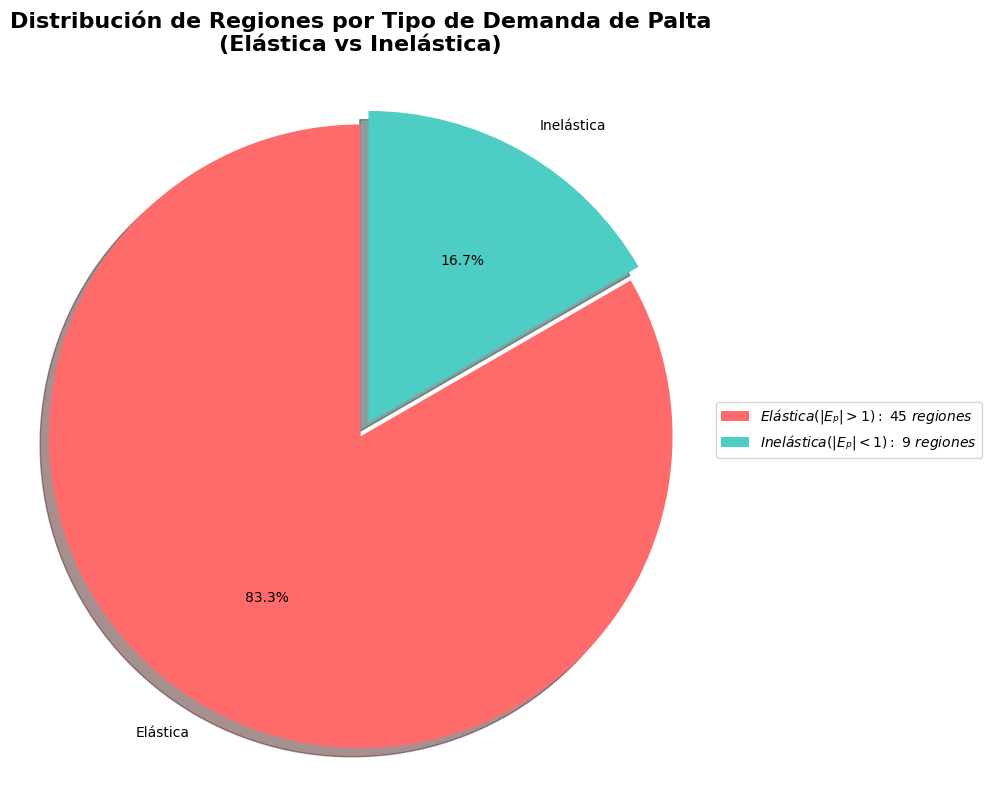

In [18]:
# Calcular la proporción de regiones por tipo de demanda
conteo_tipos = elasticidad_por_region['Tipo_Demanda'].value_counts()

# Crear el gráfico de torta
plt.figure(figsize=(10, 8))
colores = ['#FF6B6B', '#4ECDC4']  # Rojo para elástica, verde azulado para inelástica
explode = (0.05, 0)  # Resaltar la porción elástica

# Crear el pie chart
plt.pie(conteo_tipos.values,
        labels=conteo_tipos.index,
        autopct='%1.1f%%',
        colors=colores,
        explode=explode,
        shadow=True,
        startangle=90)

# Añadir título
plt.title('Distribución de Regiones por Tipo de Demanda de Palta\n(Elástica vs Inelástica)',
          fontsize=16, fontweight='bold', pad=20)

# Añadir información adicional en la leyenda
elasticas = conteo_tipos.get('Elástica', 0)
inelasticas = conteo_tipos.get('Inelástica', 0)
total_regiones = elasticas + inelasticas

leyenda_info = [
    f'$Elástica (|Eₚ| > 1):$ {elasticas} $regiones$',
    f'$Inelástica (|Eₚ| < 1):$ {inelasticas} $regiones$',
    f'Total: {total_regiones} regiones analizadas'
]

plt.legend(leyenda_info, loc='center left', bbox_to_anchor=(1, 0.5))

# Asegurar que el gráfico sea un círculo perfecto
plt.axis('equal')

plt.tight_layout()
plt.show()
plt.close()


###Resumen del Análisis de Elasticidad de la palta

El análisis de elasticidad precio de la demanda para la palta, con un promedio global de aproximadamente -1.41, indica que la demanda es **elástica** (ya que el valor absoluto, 1.41, es mayor que 1).

Esto significa que los consumidores de palta son **sensibles a los cambios en el precio**. Un cambio porcentual en el precio provoca un cambio porcentual mayor en la cantidad demandada. Esta sensibilidad sugiere fuertemente la existencia de **sustitutos disponibles** a los que los consumidores pueden recurrir si el precio de la palta sube.

Se identifican varios tipos de sustitutos potenciales dependiendo del uso producto:

*   **Como alimento saludable:** Aceite de oliva, semillas, pescado graso.
*   **En ensaladas:** Aceite de oliva con limón, nueces, quesos..

En conclusión, la elasticidad elástica observada confirma que los consumidores responden significativamente a las variaciones de precio, pudiendo optar por sustitutos cuando la palta se vuelve más caro.

### 🔍 Antes de llevar este número a una reunión

El promedio de $-1{,}41$ es un buen punto de partida, pero un analista tiene que poder defender de
dónde salió. Y si miramos la tabla de elasticidades individuales que calculamos, aparecen cosas que
hay que saber explicar:

| Lo que se ve en los datos | Qué significa |
|---|---|
| Valores como $-10{,}5$ o $-26{,}5$ | El denominador $\Delta P$ fue **casi cero**: dividir por algo diminuto hace explotar el cociente. Es el **mismo problema de amplificación** que vimos al derivar datos ruidosos en la Clase 09 |
| Elasticidades **positivas** (ej. $+2{,}89$) | Precio y cantidad subieron **juntos**. Sobre una curva de demanda normal eso es imposible: lo que se movió no fue el precio, fue **la demanda entera** (estacionalidad, publicidad) o **la oferta** |
| El rango va de $-219$ a $+277$ | Confirma lo anterior: no son elasticidades, son cocientes reventados por el denominador |

Hay una buena noticia, y conviene verificarla en vez de suponerla: **el promedio, la mediana y el
promedio recortado dan los tres casi lo mismo** ($\approx -1{,}41$). Los outliers son espectaculares
pero están repartidos a ambos lados, así que **no arrastran la medida de centro**. El valor central
es más robusto de lo que el histograma sugiere a primera vista.

La mala noticia es la otra: **una de cada cuatro observaciones tiene elasticidad positiva.** Eso no
es un detalle de limpieza, es una señal de que el cociente no está midiendo lo que creemos.

**El problema de fondo tiene nombre y es clásico en econometría.** Cada par de semanas consecutivas
nos da un precio y una cantidad, pero lo que observamos es el **punto de equilibrio** entre oferta y
demanda, no la curva de demanda. Si lo que se movió entre dos semanas fue la oferta (una helada, una
cosecha buena), el cociente estima la demanda. Si lo que se movió fue la demanda, el cociente estima
la **oferta**. Y en los datos no viene escrito cuál de los dos fue.

> 💼 **Cómo se comunica esto.** No hay que tirar el análisis: hay que acompañarlo. La frase correcta
> no es *"la demanda de palta es elástica, $\varepsilon = -1{,}41$"*, sino: *"las variaciones semanales
> de precio y cantidad son consistentes con una demanda elástica, con un $\varepsilon$ del orden de
> $-1{,}4$; el número es sensible a los outliers y no separa movimientos de oferta de movimientos de
> demanda —de hecho, el 25% de las observaciones tiene el signo cambiado—, así que sirve como orden
> de magnitud, no como parámetro para fijar precios"*.
>
> Esa diferencia entre las dos frases es, en buena medida, la diferencia entre correr el código y
> hacer análisis.


Observaciones              : 17,313
Promedio simple            :   -1.414   ← el que reportamos
Mediana                    :   -1.408   ← más robusta a outliers
Promedio recortado (5%-95%):   -1.407

Elasticidades POSITIVAS    : 4,324 (25.0% del total)
   → económicamente imposibles sobre una curva de demanda: son movimientos de oferta

Valor mínimo:       -219.1
Valor máximo:        277.0
   → ese rango delata el problema del denominador chico


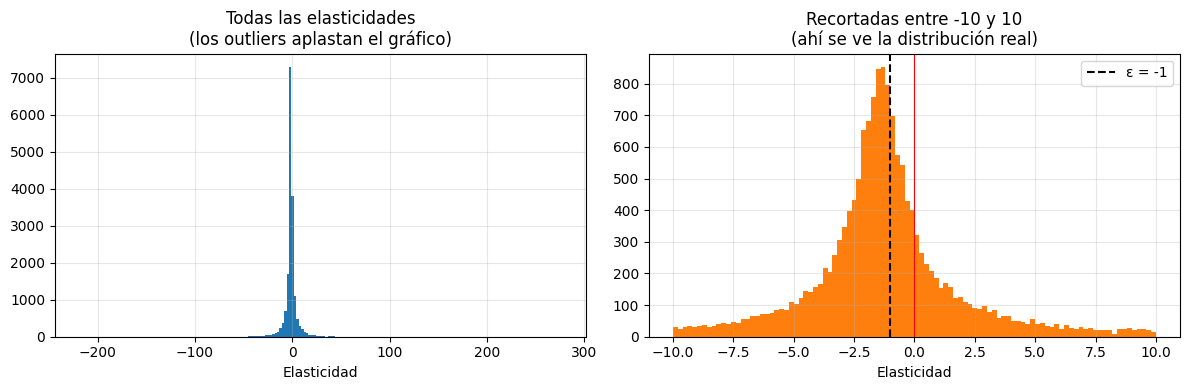

In [19]:
# Veamos cuánto cambian las conclusiones al tratar los outliers
Ep_serie = df['Elasticidad'].dropna()

print(f"Observaciones              : {len(Ep_serie):,}")
print(f"Promedio simple            : {Ep_serie.mean():>8.3f}   ← el que reportamos")
print(f"Mediana                    : {Ep_serie.median():>8.3f}   ← más robusta a outliers")
print(f"Promedio recortado (5%-95%): "
      f"{Ep_serie[(Ep_serie > Ep_serie.quantile(.05)) & (Ep_serie < Ep_serie.quantile(.95))].mean():>8.3f}")

print(f"\nElasticidades POSITIVAS    : {(Ep_serie > 0).sum():,} "
      f"({100*(Ep_serie > 0).mean():.1f}% del total)")
print("   → económicamente imposibles sobre una curva de demanda: son movimientos de oferta")

print(f"\nValor mínimo: {Ep_serie.min():>12.1f}")
print(f"Valor máximo: {Ep_serie.max():>12.1f}")
print("   → ese rango delata el problema del denominador chico")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(Ep_serie, bins=200)
ax[0].set_title("Todas las elasticidades\n(los outliers aplastan el gráfico)")
ax[1].hist(Ep_serie[(Ep_serie > -10) & (Ep_serie < 10)], bins=100, color="tab:orange")
ax[1].axvline(-1, color="black", ls="--", label="ε = -1")
ax[1].axvline(0, color="red", ls="-", lw=.8)
ax[1].set_title("Recortadas entre -10 y 10\n(ahí se ve la distribución real)")
ax[1].legend()
for a in ax: a.set_xlabel("Elasticidad"); a.grid(alpha=.3)
plt.tight_layout(); plt.show()


Veamos en graficos

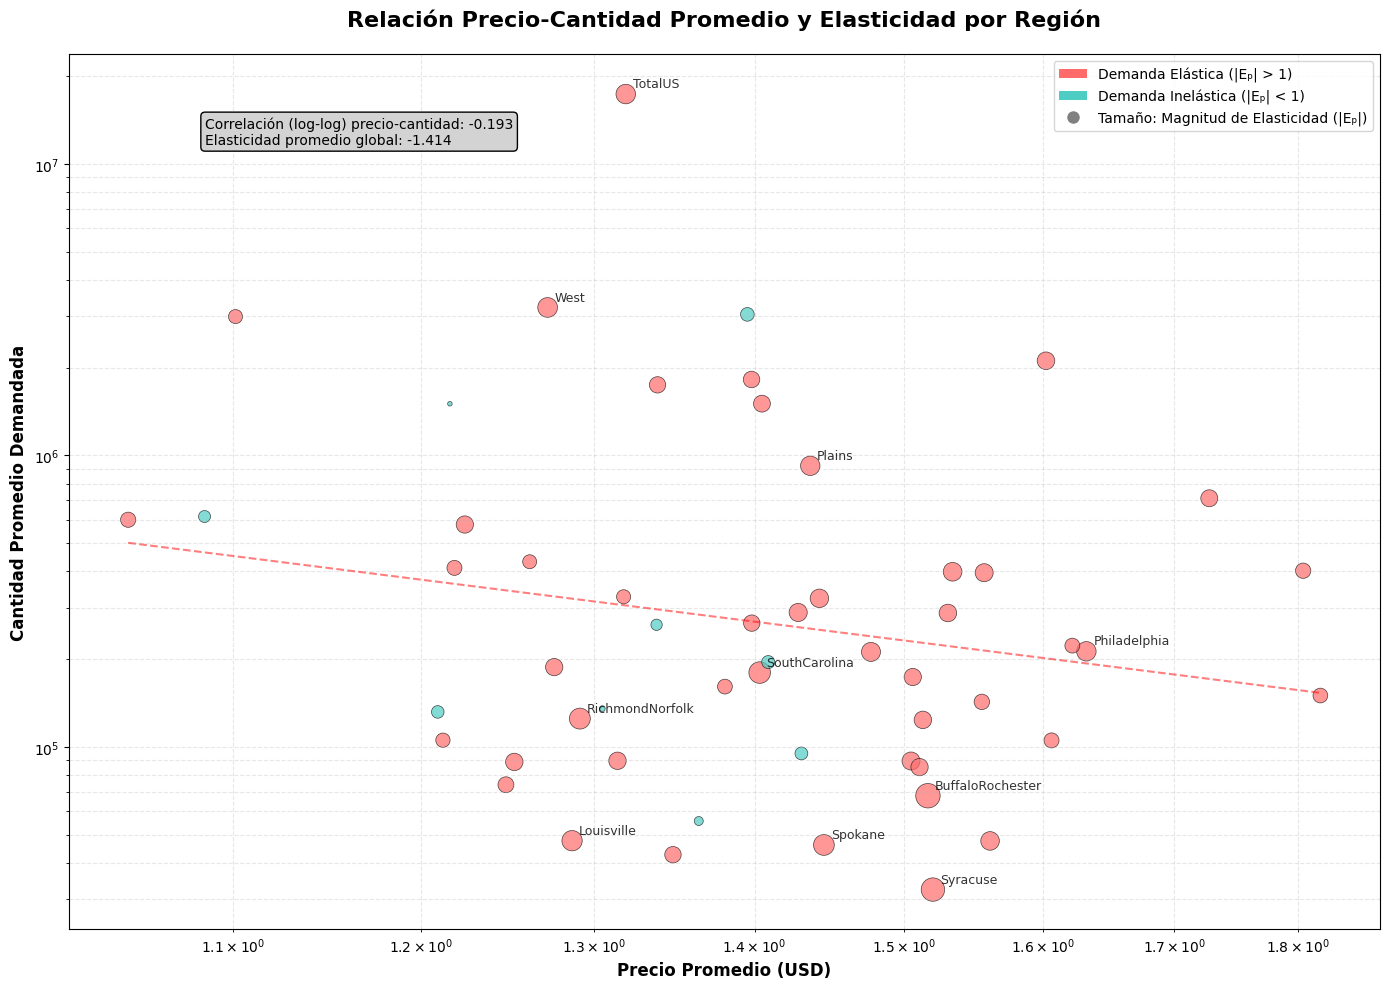

In [20]:
# Calcular precios y cantidades promedio por región para el scatter
precio_promedio = Palta_df.groupby('R')['P'].mean()
cantidad_promedio = Palta_df.groupby('R')['Q'].mean()

# Combinar con las elasticidades promedio por región (calculado previamente en df_resultados_elasticidad)
# Asegurarnos de incluir la columna 'Tipo_Demanda' en scatter_data
scatter_data = pd.DataFrame({
    'Precio_Promedio': precio_promedio,
    'Cantidad_Promedio': cantidad_promedio,
    'Elasticidad': elasticidad_por_region.set_index('Region')['Elasticidad_Promedio']
}).dropna()

# Unir con df_resultados_elasticidad para obtener la columna 'Tipo_Demanda'
scatter_data = scatter_data.merge(
    df_resultados_elasticidad[['Region', 'Tipo_Demanda']],
    left_index=True, right_on='Region', how='left'
).set_index('Region') # Volver a establecer 'Region' como índice si se desea, o usar la columna 'Region' directamente


# Crear el scatter plot
plt.figure(figsize=(14, 10))

# Colores según tipo de demanda (ahora 'Tipo_Demanda' está en scatter_data)
colores = ['#FF6B6B' if row['Tipo_Demanda'] == 'Elástica' else '#4ECDC4' for index, row in scatter_data.iterrows()]
tamanos = np.abs(scatter_data['Elasticidad']) * 100  # Tamaño proporcional a la magnitud de la elasticidad

# Crear scatter plot
scatter = plt.scatter(scatter_data['Precio_Promedio'],
                     scatter_data['Cantidad_Promedio'],
                     c=colores,
                     s=tamanos,
                     alpha=0.7,
                     edgecolors='black',
                     linewidth=0.5)

# Añadir etiquetas para algunas regiones destacadas (ej. las 5 con mayor y menor elasticidad en valor absoluto)
# Identificar las regiones con elasticidades más extremas en valor absoluto
scatter_data['Abs_Elasticidad'] = abs(scatter_data['Elasticidad'])
top_bottom_elasticity = scatter_data.sort_values('Abs_Elasticidad', ascending=False).head(10) # Top 10 en valor absoluto

for region, row in top_bottom_elasticity.iterrows():
    plt.annotate(region,
                (row['Precio_Promedio'], row['Cantidad_Promedio']),
                xytext=(5, 5), textcoords='offset points',
                fontsize=9, alpha=0.8)


# Calcular y añadir línea de tendencia
if len(scatter_data) > 1:
    # Usar logaritmo para el ajuste lineal si se usó escala logarítmica en los ejes
    if scatter_data['Precio_Promedio'].min() > 0 and scatter_data['Cantidad_Promedio'].min() > 0:
        z = np.polyfit(np.log(scatter_data['Precio_Promedio']), np.log(scatter_data['Cantidad_Promedio']), 1)
        # La ecuación de la tendencia en escala original es Q = exp(z[1]) * P^z[0]
        # Para graficar la línea de tendencia en escala log-log, graficamos la línea en la escala logarítmica
        x_trend = np.linspace(scatter_data['Precio_Promedio'].min(), scatter_data['Precio_Promedio'].max(), 100)
        y_trend = np.exp(z[1]) * (x_trend**z[0])

        plt.plot(x_trend, y_trend, "r--", alpha=0.5, label=f'Tendencia: Q ≈ {np.exp(z[1]):.2f} * P^{z[0]:.2f}')


# Personalizar el gráfico
plt.title('Relación Precio-Cantidad Promedio y Elasticidad por Región',
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Precio Promedio (USD)', fontsize=12, fontweight='bold')
plt.ylabel('Cantidad Promedio Demandada', fontsize=12, fontweight='bold')
plt.xscale('log')  # Escala logarítmica para mejor visualización
plt.yscale('log')
plt.grid(True, which="both", alpha=0.3, linestyle='--')

# Añadir leyenda
from matplotlib.patches import Patch
leyenda_elementos = [
    Patch(facecolor='#FF6B6B', label='Demanda Elástica (|Eₚ| > 1)'),
    Patch(facecolor='#4ECDC4', label='Demanda Inelástica (|Eₚ| < 1)'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='gray',
              markersize=10, label='Tamaño: Magnitud de Elasticidad (|Eₚ|)')
]
plt.legend(handles=leyenda_elementos, loc='best')

# Añadir coeficiente de correlación (en escala logarítmica si se usó para la tendencia)
# Correlación entre los logaritmos
if scatter_data['Precio_Promedio'].min() > 0 and scatter_data['Cantidad_Promedio'].min() > 0:
    correlacion_log = np.corrcoef(np.log(scatter_data['Precio_Promedio']), np.log(scatter_data['Cantidad_Promedio']))[0, 1]
    correlacion_text = f'Correlación (log-log) precio-cantidad: {correlacion_log:.3f}'
else:
    correlacion_text = f'Correlación precio-cantidad: {scatter_data["Precio_Promedio"].corr(scatter_data["Cantidad_Promedio"]):.3f}'


plt.figtext(0.15, 0.85,
           f'{correlacion_text}\n'
           f'Elasticidad promedio global: {df_elasticidades["Elasticidad"].mean():.3f}',
           bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgray"))

plt.tight_layout()
plt.show()

---
# 📝 Ejercicios de práctica

Van de menor a mayor dificultad. **Intentalos primero**: la solución está en un bloque desplegable
debajo de cada uno, y abrirla antes de pelearlo no sirve de nada.

| | Ejercicio | De qué se trata |
|---|---|---|
| 1 | La cafetería | Elasticidad puntual y decisión de precio |
| 2 | Demanda de elasticidad constante | Por qué no toda demanda cambia de elasticidad |
| 3 | Arco vs. punto | Las dos fórmulas sobre los mismos datos |
| 4 | Elasticidad cruzada 🥑 | Sustitutos y complementarios, sobre datos |

> 💡 En todos, el último punto es de **interpretación**. Un número de elasticidad sin una frase que
> diga qué hacer con él no resuelve nada.


### ✅ Ejercicio 1 — La cafetería

Una cafetería estimó que la demanda diaria de café responde a:

$$Q(P) = 480 - 60P$$

donde $P$ está en miles de pesos y $Q$ en tazas por día. Hoy cobra **\$ 2.500** la taza.

**Se pide:**

1. Calculá $dQ/dP$ y escribí la elasticidad $\varepsilon(P)$ como **función del precio** con SymPy.
2. Evaluala en el precio actual. ¿La demanda es elástica o inelástica ahí?
3. Encontrá el precio donde $\varepsilon = -1$ y verificá que es el que maximiza el ingreso.
4. **La decisión:** el dueño quiere saltar a **\$ 5.000** la taza para "ganar más". Con los números
   en la mano, ¿qué le contestás? Calculá el ingreso a \$ 2.500, a \$ 4.000 y a \$ 5.000 para
   respaldar la respuesta.


In [21]:
# Tu código acá


<details>
<summary>💡 <b>Ver solución del Ejercicio 1</b></summary>

```python
import sympy as sp, numpy as np, matplotlib.pyplot as plt

P = sp.symbols("P", positive=True)
Q = 480 - 60*P

# 1) Elasticidad como función del precio
dQ_dP = sp.diff(Q, P)
eps   = sp.simplify(dQ_dP * P / Q)
print("dQ/dP =", dQ_dP)
print("ε(P)  =", eps)

# 2) En el precio actual (P = 2.5, en miles)
print(f"\nε(2.5) = {float(eps.subs(P, 2.5)):.4f}  → |ε| < 1: la demanda es INELÁSTICA acá")
print(f"Q(2.5) = {float(Q.subs(P, 2.5)):.0f} tazas")

# 3) Precio de elasticidad unitaria y máximo de ingreso
I = sp.expand(P * Q)
p_unit = sp.solve(sp.Eq(eps, -1), P)[0]
p_max  = sp.solve(sp.diff(I, P), P)[0]
print(f"\nPrecio con ε = -1        : {p_unit}")
print(f"Precio que maximiza I(P) : {p_max}   ← el mismo")

# 4) Comparación de ingresos
for precio in [2.5, 4, 5]:
    print(f"P = {precio:>4.1f} → Q = {float(Q.subs(P,precio)):>6.0f} tazas, "
          f"I = {float(I.subs(P,precio)):>8.0f} (miles)")
```

**La respuesta al dueño (punto 4).** En el precio actual la elasticidad es $\varepsilon(2{,}5) \approx
-0{,}45$: la demanda es **inelástica**, así que la intuición del dueño va en la dirección correcta.
Subir el precio **sí** aumenta el ingreso, porque la cantidad cae proporcionalmente menos de lo que
sube el precio.

Pero se pasa de largo. El ingreso crece solo hasta \$ 4.000, que es donde $\varepsilon = -1$. De ahí
en adelante la demanda se vuelve elástica y subir más **destruye** ingreso:

| Precio | Tazas | Ingreso | $\varepsilon$ |
|---|---|---|---|
| \$ 2.500 (hoy) | 330 | 825 | $-0{,}45$ inelástica |
| \$ 4.000 | 240 | **960** ← máximo | $-1{,}00$ unitaria |
| \$ 5.000 (su idea) | 180 | 900 | $-1{,}67$ elástica |

Así que la respuesta es: *"subir está bien, \$ 5.000 es demasiado"*. A \$ 5.000 factura más que hoy,
pero menos que a \$ 4.000, y encima pierde 60 clientes por día.

**Y la advertencia que va siempre:** esto maximiza el **ingreso**, no el **beneficio**. Cada taza
tiene un costo. Si hacer un café cuesta \$ 1.500, el precio que maximiza el beneficio es **más alto**
que \$ 4.000, porque vender menos tazas también ahorra costos. Ese es exactamente el paso que damos
en la Clase 11.

</details>


### ✅ Ejercicio 2 — Demanda de elasticidad constante

En el Ejercicio 1 la elasticidad cambiaba en cada punto. Eso pasa porque la demanda es **lineal**,
no porque sea una ley universal. Probemos con otra forma funcional, muy usada en econometría:

$$Q(P) = A \cdot P^{-b} \qquad \text{con } A > 0,\; b > 0$$

**Se pide:**

1. Calculá $\varepsilon(P)$ **simbólicamente**, dejando $A$ y $b$ como símbolos. Simplificá.
2. ¿De qué depende el resultado? ¿Aparece $P$ en alguna parte?
3. Tomá $A = 5.000$ y $b = 1{,}8$. Evaluá la elasticidad en $P = 1$, $P = 10$ y $P = 100$.
4. Graficá las dos demandas juntas (la lineal del Ejercicio 1 y esta) con sus elasticidades debajo,
   para ver la diferencia.
5. **Interpretación:** si estimás una demanda con este modelo, ¿qué estás **suponiendo** sobre el
   comportamiento de los consumidores? ¿Cuándo ese supuesto sería un problema?

> 💡 Pista para el punto 1: conviene declarar los símbolos con `positive=True`. Sin eso, SymPy no
> puede simplificar la potencia.


In [22]:
# Tu código acá


<details>
<summary>💡 <b>Ver solución del Ejercicio 2</b></summary>

```python
import sympy as sp, numpy as np, matplotlib.pyplot as plt

# 1) Las assumptions son necesarias acá: sin positive=True no simplifica
P, A, b = sp.symbols("P A b", positive=True)

Q = A * P**(-b)
eps = sp.simplify(sp.diff(Q, P) * P / Q)

print("Q(P) =", Q)
print("ε(P) =", eps, "  ← ¡no aparece P!")

# 3) Valores concretos
valores = {A: 5000, b: 1.8}
for precio in [1, 10, 100]:
    print(f"P = {precio:>4} → Q = {float(Q.subs(valores).subs(P,precio)):>10.2f}, "
          f"ε = {float(eps.subs(valores).subs(P,precio)):.4f}")

# 4) Comparación gráfica con la demanda lineal del Ejercicio 1
Q_lin = 480 - 60*P
eps_lin = sp.simplify(sp.diff(Q_lin, P) * P / Q_lin)

p_vals = np.linspace(0.5, 7.5, 300)
Q_lin_f   = sp.lambdify(P, Q_lin)
eps_lin_f = sp.lambdify(P, eps_lin)
Q_pot_f   = sp.lambdify(P, Q.subs(valores))
# Ojo: eps.subs(valores) es la CONSTANTE -1.8, no depende de P.
# lambdify devolvería un escalar, así que lo repetimos a lo largo del eje a mano.
eps_pot_vals = np.full_like(p_vals, float(eps.subs(valores)))

fig, ax = plt.subplots(2, 2, figsize=(12, 7), sharex=True)
ax[0,0].plot(p_vals, Q_lin_f(p_vals), lw=2.5);  ax[0,0].set_title("Demanda LINEAL")
ax[1,0].plot(p_vals, eps_lin_f(p_vals), lw=2.5, color="tab:red"); ax[1,0].set_ylim(-6, 0)
ax[1,0].set_title("su elasticidad: CAMBIA")
ax[0,1].plot(p_vals, Q_pot_f(p_vals), lw=2.5);  ax[0,1].set_title("Demanda POTENCIA")
ax[1,1].plot(p_vals, eps_pot_vals, lw=2.5, color="tab:red"); ax[1,1].set_ylim(-6, 0)
ax[1,1].set_title("su elasticidad: CONSTANTE en -1.8")
for a in (ax[1,0], ax[1,1]):
    a.axhline(-1, color="black", ls="--", lw=.8)
for a in ax.flat:
    a.grid(alpha=.3); a.set_xlabel("Precio")
plt.tight_layout(); plt.show()
```

**El resultado (puntos 1 y 2).** $\varepsilon = -b$, y **$P$ desaparece**. La cuenta es directa:

$$\varepsilon = \frac{dQ}{dP}\cdot\frac{P}{Q} = \left(-bAP^{-b-1}\right)\cdot\frac{P}{AP^{-b}} = -b$$

Por eso a esta forma funcional se la llama **de elasticidad constante**: la elasticidad es el
exponente, igual en todos los precios. Y de ahí viene su popularidad en econometría — si tomás
logaritmos queda $\ln Q = \ln A - b \ln P$, o sea una **regresión lineal en logs cuyo coeficiente
$b$ es directamente la elasticidad**.

**Interpretación (punto 5).** Usar este modelo es suponer que los consumidores reaccionan **igual en
términos porcentuales a cualquier precio**: que subir de \$ 100 a \$ 101 provoca la misma caída
porcentual que subir de \$ 10.000 a \$ 10.100.

Es un supuesto cómodo y a veces razonable en un rango acotado de precios. Es un problema cuando el
rango es amplio, y sobre todo cerca de los extremos: este modelo dice que **nunca** hay un precio tan
alto que la cantidad llegue a cero, lo cual es falso para cualquier producto real.

**La moraleja:** la elasticidad que estimás depende de la **forma funcional que elegiste**, no solo
de los datos. Elegirla no es un trámite.

</details>


### ✅ Ejercicio 3 — Arco vs. punto sobre los mismos datos

Una distribuidora probó cinco precios distintos y registró las ventas semanales:

| Precio (\$) | 400 | 600 | 800 | 1.000 | 1.200 |
|---|---|---|---|---|---|
| **Unidades** | 3.050 | 2.480 | 2.010 | 1.490 | 980 |

**Se pide:**

1. Calculá la **elasticidad de arco** entre cada par de precios consecutivos (cuatro valores), con
   el método del punto medio.
2. Calculá también la elasticidad **sin** punto medio, usando $\frac{\Delta Q / Q_0}{\Delta P / P_0}$
   (es decir, dividiendo por el valor inicial en vez del promedio). Compará las dos series.
3. ¿En qué tramo la demanda pasa de inelástica a elástica?
4. Ajustá una recta a los cinco puntos con `np.polyfit` y calculá la elasticidad **puntual** en
   cada uno de los cinco precios. Compará contra las de arco.
5. **Interpretación:** ¿por qué el método del punto medio es el que se usa por convención? Pensá qué
   pasa si calculás la elasticidad de \$ 800 a \$ 1.200 y después de \$ 1.200 a \$ 800.


In [23]:
# Tu código acá


<details>
<summary>💡 <b>Ver solución del Ejercicio 3</b></summary>

```python
import numpy as np

precio   = np.array([400., 600., 800., 1000., 1200.])
unidades = np.array([3050., 2480., 2010., 1490., 980.])

# 1) y 2) Las dos versiones
dP, dQ = np.diff(precio), np.diff(unidades)
P0, Q0 = precio[:-1], unidades[:-1]
P_med  = (precio[1:] + precio[:-1]) / 2
Q_med  = (unidades[1:] + unidades[:-1]) / 2

eps_arco  = (dQ / Q_med) / (dP / P_med)     # punto medio
eps_base0 = (dQ / Q0)    / (dP / P0)        # base en el valor inicial

print(f"{'tramo':>16}{'arco':>10}{'base inicial':>15}{'tipo':>14}")
for i in range(len(eps_arco)):
    tipo = "elástica" if abs(eps_arco[i]) > 1 else "inelástica"
    print(f"{precio[i]:>7.0f}→{precio[i+1]:<8.0f}{eps_arco[i]:>10.3f}"
          f"{eps_base0[i]:>15.3f}{tipo:>14}")

# 4) Elasticidad puntual sobre la recta ajustada
b, a = np.polyfit(precio, unidades, 1)       # Q = a + b·P
print(f"\nRecta ajustada: Q = {a:.1f} + ({b:.4f})·P")
print(f"\n{'precio':>10}{'ε puntual':>12}")
for p_i in precio:
    q_i = a + b*p_i
    print(f"{p_i:>10.0f}{b * p_i / q_i:>12.3f}")

# 5) La asimetría del método ingenuo
sube = ((unidades[-1]-unidades[0])/unidades[0]) / ((precio[-1]-precio[0])/precio[0])
baja = ((unidades[0]-unidades[-1])/unidades[-1]) / ((precio[0]-precio[-1])/precio[-1])
med  = ((unidades[-1]-unidades[0])/((unidades[-1]+unidades[0])/2)) / \
       ((precio[-1]-precio[0])/((precio[-1]+precio[0])/2))
print(f"\nDe 400 a 1200, base inicial : {sube:.4f}")
print(f"De 1200 a 400, base inicial : {baja:.4f}   ← ¡distinto!")
print(f"Con punto medio, en cualquier sentido: {med:.4f}")
```

**El cruce (punto 3).** Los dos primeros tramos son **inelásticos** ($-0{,}52$ y $-0{,}73$) y los dos
últimos **elásticos** ($-1{,}34$ y $-2{,}27$). El cruce de $\varepsilon = -1$ ocurre **dentro del
tramo \$ 800 → \$ 1.000**, que es exactamente lo que predice el Ejercicio 2 para una demanda casi
lineal: $|\varepsilon|$ crece con el precio.

Ahí está, además, la respuesta de gestión: **el precio que maximiza el ingreso está en algún lugar
entre \$ 800 y \$ 1.000**, y la elasticidad de arco lo acorraló sin necesidad de estimar ninguna
curva.

**Por qué el punto medio (punto 5).** Porque el método ingenuo **no es simétrico**: da un número
distinto según si pensás el movimiento como una suba o como una baja, aunque sea exactamente el mismo
par de puntos. Eso es inaceptable — la elasticidad entre dos puntos no puede depender de cuál
llamaste "inicial".

El método del punto medio divide por el **promedio** de los dos valores, que es el mismo en las dos
direcciones. Por eso también se lo llama **elasticidad arco**: describe el arco entre dos puntos, sin
privilegiar ninguno.

**Y la conexión con la Clase 09:** la elasticidad de arco es una **diferencia finita**, y la puntual
es una **derivada**. Cuanto más juntos están los dos precios, más se parecen — es el mismo límite
$h \to 0$ de siempre. Con precios separados de a \$ 100, la diferencia ya se nota.

</details>


### ✅ Ejercicio 4 — Elasticidad cruzada 🥑

Hasta acá medimos cómo responde la cantidad de un producto a **su propio** precio. Pero también
importa cómo responde al precio de **otro** producto. Eso es la **elasticidad cruzada**:

$$\varepsilon_{xy} = \frac{\%\Delta Q_x}{\%\Delta P_y}$$

Y su **signo** es lo que la hace útil:

| Signo | Qué significa | Ejemplo |
|---|---|---|
| $\varepsilon_{xy} > 0$ | **Sustitutos**: sube el precio de $y$ y se vende más $x$ | café y té |
| $\varepsilon_{xy} < 0$ | **Complementarios**: sube el precio de $y$ y se vende menos $x$ | autos y nafta |
| $\varepsilon_{xy} \approx 0$ | No relacionados | paltas y cemento |

El dataset de paltas tiene dos tipos de palta (columna `type`: `conventional` y `organic`). La
pregunta de negocio es directa: **¿son sustitutos entre sí?**

**Se pide:**

1. Volvé a cargar el dataset completo (necesitamos la columna `type`, que descartamos antes).
2. Quedate con **una sola región** (por ejemplo `"Albany"`) y armá una tabla con una fila por fecha
   y dos columnas de precio y dos de cantidad, una por tipo.
3. Calculá la elasticidad cruzada de arco de la **cantidad de palta convencional** respecto del
   **precio de la palta orgánica**, entre fechas consecutivas. Usá la **mediana**, no el promedio
   (ya vimos por qué).
4. Calculá también la elasticidad **propia** de la convencional, para comparar magnitudes.
5. **Interpretación:** ¿el signo da lo que esperabas? ¿Qué tan convencido estás del resultado?
   Repetí el cálculo para dos o tres regiones más y mirá si el signo se mantiene.


In [24]:
# Tu código acá


<details>
<summary>💡 <b>Ver solución del Ejercicio 4</b></summary>

```python
import pandas as pd, numpy as np

URL = ("https://raw.githubusercontent.com/Datso653/Laboratorio-de-metodos-"
       "Cuantitativos-Aplicados-a-la-gestion/main/DF/avocado.csv")
df = pd.read_csv(URL)

def cruzada(region):
    d = df[df["region"] == region].copy()
    # 2) una fila por fecha, una columna por tipo
    tabla = d.pivot_table(index="Date", columns="type",
                          values=["AveragePrice", "Total Volume"]).dropna().sort_index()

    Pc = tabla[("AveragePrice", "conventional")].values
    Po = tabla[("AveragePrice", "organic")].values
    Qc = tabla[("Total Volume", "conventional")].values

    def var_pct(v):                       # variación porcentual con punto medio
        return (v[1:] - v[:-1]) / ((v[1:] + v[:-1]) / 2)

    vQc, vPo, vPc = var_pct(Qc), var_pct(Po), var_pct(Pc)

    # 3) y 4) elasticidad cruzada y propia, ignorando denominadores casi nulos
    def elast(num, den, umbral=0.01):
        ok = np.abs(den) > umbral
        return np.median(num[ok] / den[ok]), ok.sum()

    e_cruz, n1 = elast(vQc, vPo)
    e_prop, n2 = elast(vQc, vPc)
    return e_cruz, e_prop, n1, n2

print(f"{'Región':<16}{'ε cruzada':>12}{'ε propia':>12}{'n':>8}")
for reg in ["Albany", "Chicago", "Houston", "Seattle", "TotalUS"]:
    ec, ep, n1, n2 = cruzada(reg)
    print(f"{reg:<16}{ec:>12.3f}{ep:>12.3f}{n1:>8}")
```

**Qué sale, y por qué el ejercicio vale la pena (punto 5).** Si esperabas un signo positivo claro y
estable, **no es lo que devuelven los datos**. Las cruzadas salen chiquitas y **con el signo cambiado
según la región**: positivas en algunas ciudades, negativas en otras, y todas cerca de cero. La
elasticidad **propia**, en cambio, sale consistentemente alrededor de $-1$ en todas las regiones.

Ese contraste es el resultado del ejercicio. Cuando un efecto es real y fuerte, aparece parecido en
todas las submuestras — como pasa con la propia. Cuando el signo se da vuelta según la ciudad y las
magnitudes son diez veces más chicas, **lo que estás midiendo es probablemente ruido**.

Los tres motivos de fondo:

1. **El problema de identificación es el mismo de antes, y acá es peor:** los precios de los dos
   tipos se mueven por causas **comunes** (clima, combustible, temporada). Cualquier correlación
   entre ellos puede ser eso y nada más.
2. **Los dos tipos no son un mercado único.** La palta orgánica mueve volúmenes mucho menores y
   compite con un público distinto: la sustitución, si existe, puede ser muy asimétrica.
3. **Las decisiones de cálculo pesan.** Usamos mediana y filtramos $|\Delta P| < 1\%$; con otro
   umbral los números cambian. Un resultado sensible a eso hay que reportarlo junto con la decisión.

**La conclusión honesta:** *"la evidencia es compatible con que sean sustitutos, con una cruzada
positiva y chica frente a la propia; no es una estimación causal y no la usaría para fijar precios
sin un diseño que separe los movimientos de oferta de los de demanda"*.

</details>


In [25]:
#@title Easter egg 🥚
from IPython.display import Image
Image(url='https://media1.giphy.com/media/v1.Y2lkPTc5MGI3NjExbThjMmhzdWhxd3U5YjllZ3drY21pNDJsYnJ4a2x0NGsxNm51Y2Q5cSZlcD12MV9pbnRlcm5hbF9naWZfYnlfaWQmY3Q9Zw/lKQ4k6JMgf1OoeIcVf/giphy.gif')